## Percobaan 2

In [2]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Library yang Digunakan

Proyek ini menggunakan beberapa library Python untuk mendukung proses pengolahan citra, ekstraksi fitur tekstur, visualisasi data, serta klasifikasi penyakit daun mangga. Library `os` digunakan untuk mengakses struktur folder dataset dan membaca seluruh file citra yang terdapat pada setiap kelas. Dengan library ini, program dapat mengambil lokasi file secara otomatis sehingga proses pemuatan dataset menjadi lebih mudah.

Library OpenCV (`cv2`) digunakan pada tahap preprocessing citra. OpenCV berfungsi untuk membaca citra dari dataset, mengubah citra berwarna menjadi grayscale, melakukan resize agar seluruh citra memiliki ukuran yang sama, serta menerapkan metode CLAHE (Contrast Limited Adaptive Histogram Equalization) untuk meningkatkan kualitas kontras citra sebelum dilakukan ekstraksi fitur.

Untuk kebutuhan visualisasi, proyek ini menggunakan Matplotlib (`matplotlib.pyplot`). Library ini digunakan untuk menampilkan grafik distribusi dataset, menampilkan hasil preprocessing citra, serta menampilkan confusion matrix dari hasil klasifikasi sehingga performa model dapat diamati dengan lebih jelas.

Proses pengolahan data numerik didukung oleh NumPy (`numpy`). Library ini digunakan untuk menyimpan citra dalam bentuk array, melakukan konversi tipe data, serta membantu berbagai operasi numerik yang dibutuhkan selama proses pengolahan citra dan ekstraksi fitur.

Pandas (`pandas`) digunakan untuk mengelola data hasil ekstraksi fitur dalam bentuk DataFrame. Hasil ekstraksi kemudian disimpan ke dalam file CSV dan digunakan kembali sebagai dataset pada tahap klasifikasi.

Ekstraksi fitur tekstur dilakukan menggunakan library scikit-image (`skimage.feature`) melalui metode Gray Level Co-occurrence Matrix (GLCM). Fungsi `graycomatrix()` digunakan untuk membentuk matriks GLCM, sedangkan `graycoprops()` digunakan untuk menghitung berbagai fitur tekstur seperti Contrast, Homogeneity, Dissimilarity, Correlation, ASM, dan Energy.

Selain itu, SciPy (`scipy.stats`) digunakan untuk menghitung nilai Entropy dari matriks GLCM. Fitur ini digunakan untuk memberikan informasi tambahan mengenai tingkat kompleksitas tekstur pada citra yang dianalisis.

Tahap klasifikasi memanfaatkan Scikit-Learn (`sklearn`). Library ini digunakan untuk membagi dataset menjadi data latih dan data uji menggunakan `train_test_split()`, membangun model klasifikasi menggunakan algoritma Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN), serta melakukan evaluasi performa model menggunakan accuracy score, classification report, dan confusion matrix.

Library Seaborn (`seaborn`) juga diimpor pada program. Namun, pada implementasi saat ini library tersebut belum digunakan secara langsung sehingga dapat dihapus tanpa memengaruhi jalannya program.


Total Dataset : 2000

Jumlah Data per Kelas:
Counter({np.str_('Bacterial Canker'): 500, np.str_('Die Back'): 500, np.str_('Healthy'): 500, np.str_('Sooty Mould'): 500})


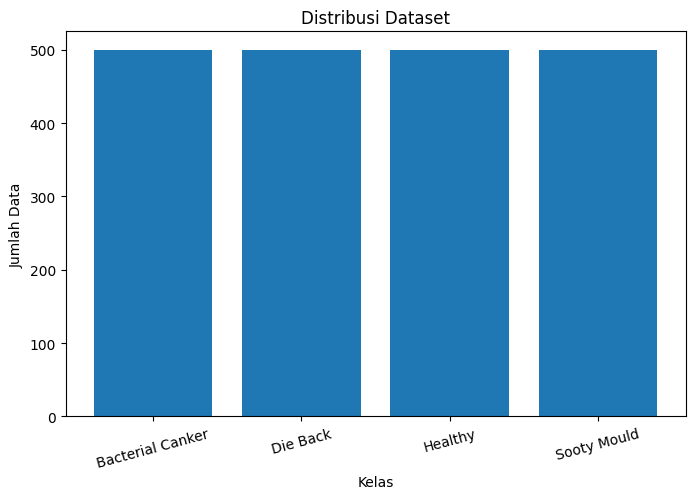

In [3]:
data = []
labels = []
file_name = []

path_dataset = "Assets/"

target_classes = [
    "Bacterial Canker",
    "Die Back",
    "Healthy",
    "Sooty Mould"
]

for sub_folder in target_classes:
    path_sub_folder = os.path.join(path_dataset, sub_folder)
    
    sub_folder_files = os.listdir(path_sub_folder)
    
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(path_sub_folder, filename)
        img = cv.imread(img_path)
        
        if img is not None:
            img = img.astype(np.uint8)
            
            data.append(img)
            labels.append(sub_folder)
            file_name.append(filename)
            
data = np.array(data, dtype=object)
labels = np.array(labels)

from collections import Counter

print("Total Dataset :", len(labels))
print("\nJumlah Data per Kelas:")
print(Counter(labels))

jumlah_kelas = Counter(labels)

plt.figure(figsize=(8,5))
plt.bar(jumlah_kelas.keys(), jumlah_kelas.values())
plt.title("Distribusi Dataset")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=15)
plt.show()

## Memuat Dataset dan Analisis Distribusi Data

Pada tahap awal, program memuat dataset citra daun mangga yang digunakan untuk proses klasifikasi penyakit. Dataset terdiri dari **2.000 citra** yang terbagi ke dalam empat kelas, yaitu **Bacterial Canker**, **Die Back**, **Healthy**, dan **Sooty Mould**. Setiap kelas memiliki **500 citra**, sehingga distribusi data pada dataset bersifat seimbang. Seluruh citra disimpan dalam folder terpisah di dalam direktori `assets`, sehingga proses pelabelan dapat dilakukan secara otomatis berdasarkan nama folder masing-masing kelas.

Untuk membaca dataset, program menggunakan fungsi `os.listdir()` untuk mengambil seluruh file citra yang terdapat pada setiap folder kelas. Selanjutnya, fungsi `os.path.join()` digunakan untuk membangun path file secara otomatis, sedangkan `cv.imread()` digunakan untuk membaca citra ke dalam memori. Setiap citra yang berhasil dimuat disimpan ke dalam variabel `data`, label kelas disimpan pada variabel `labels`, dan nama file citra disimpan pada variabel `file_name`.

Setelah seluruh citra berhasil dimuat, data dikonversi ke dalam format NumPy Array agar lebih mudah diproses pada tahapan berikutnya. Proses ini menghasilkan kumpulan data citra beserta label yang akan digunakan pada tahap preprocessing, ekstraksi fitur tekstur menggunakan GLCM, serta proses klasifikasi menggunakan algoritma machine learning.

Untuk menganalisis komposisi dataset, program menghitung jumlah citra pada setiap kelas menggunakan `Counter(labels)`. Hasil perhitungan tersebut kemudian ditampilkan dalam bentuk teks dan divisualisasikan menggunakan grafik batang (bar chart) melalui Matplotlib. Grafik distribusi dataset menampilkan jumlah citra pada masing-masing kelas sehingga pengguna dapat melihat persebaran data secara visual.

Berdasarkan hasil visualisasi, diketahui bahwa setiap kelas memiliki jumlah data yang sama, yaitu 500 citra. Kondisi ini menunjukkan bahwa dataset berada dalam keadaan seimbang (*balanced dataset*), sehingga setiap kelas memiliki representasi yang setara selama proses pelatihan model. Dataset yang seimbang sangat penting dalam klasifikasi karena dapat mengurangi potensi bias model terhadap kelas tertentu dan membantu menghasilkan performa klasifikasi yang lebih objektif.

Analisis distribusi data pada tahap ini menjadi langkah awal untuk memastikan bahwa dataset yang digunakan telah memiliki kualitas yang baik sebelum memasuki tahap preprocessing, ekstraksi fitur, dan pembangunan model klasifikasi. Dengan distribusi yang merata pada setiap kelas, hasil evaluasi model nantinya dapat lebih mencerminkan kemampuan model dalam membedakan karakteristik masing-masing penyakit daun mangga.

Memproses Grayscale -> Resize ...
Pemrosesan Selesai! Menampilkan hasil Resize...


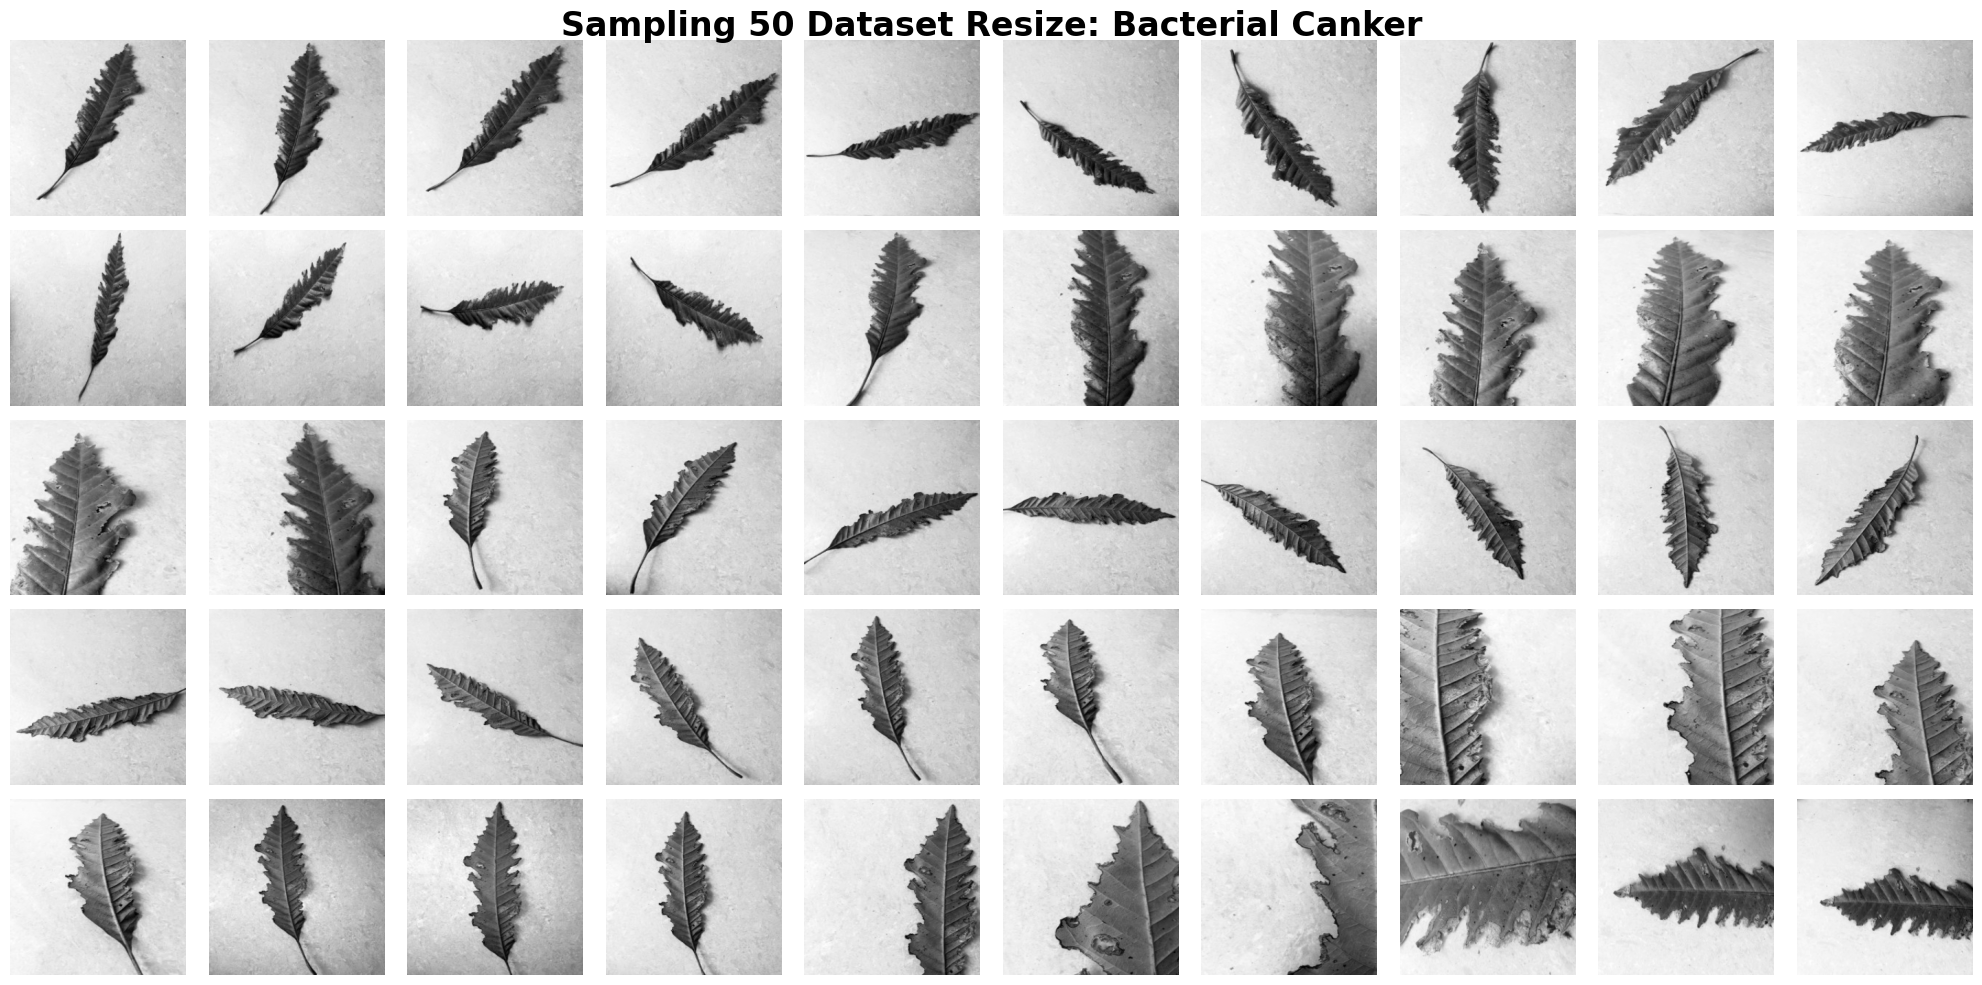

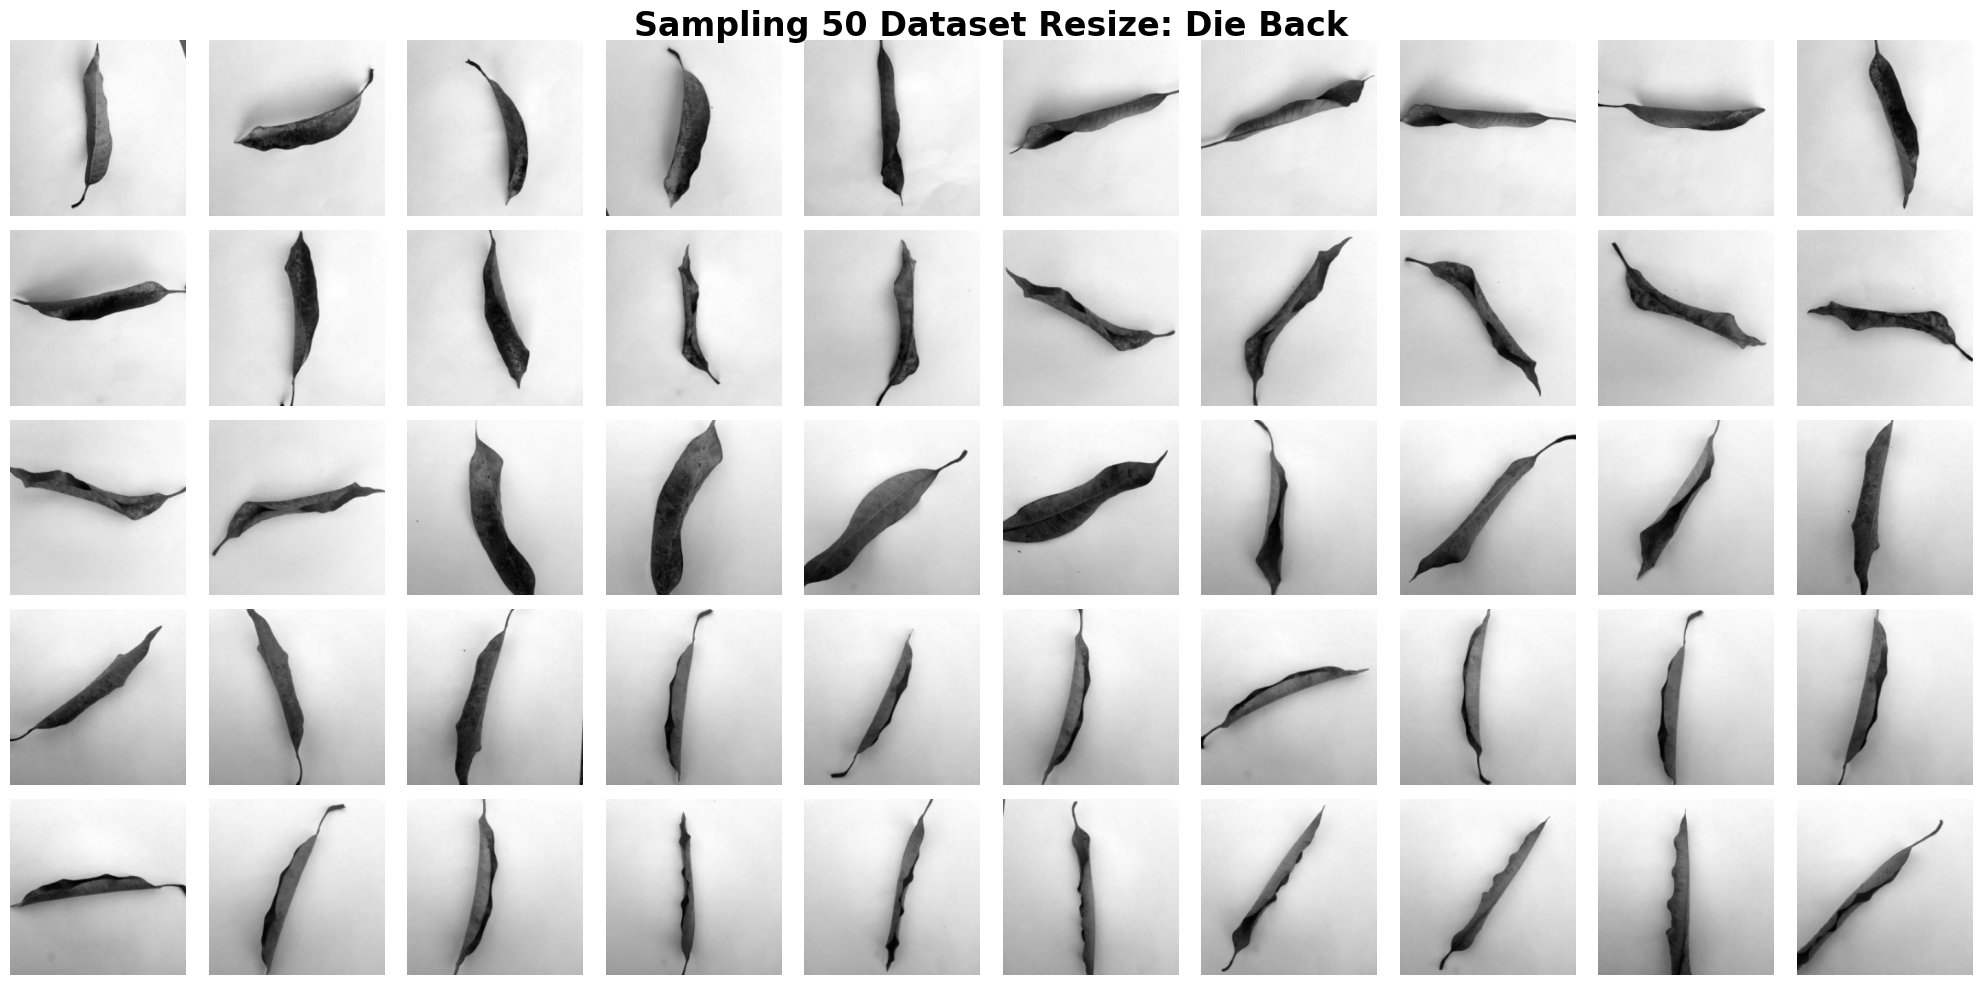

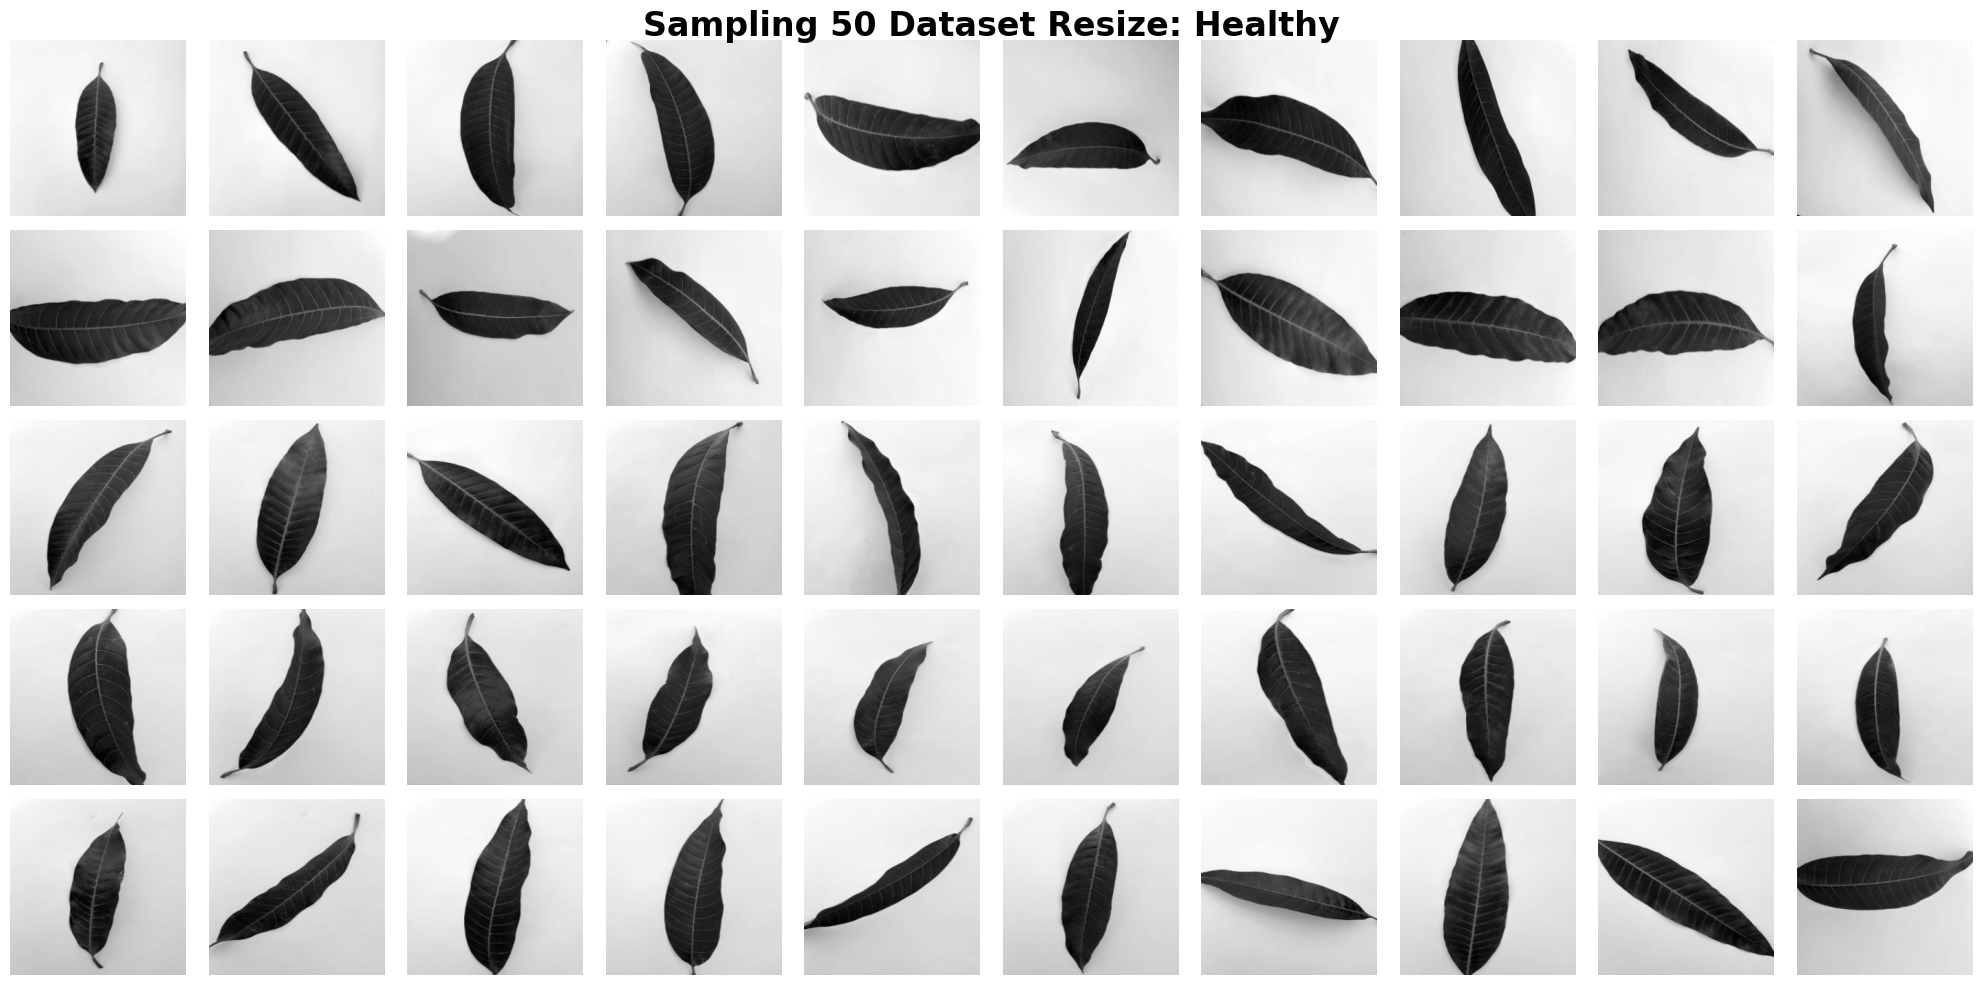

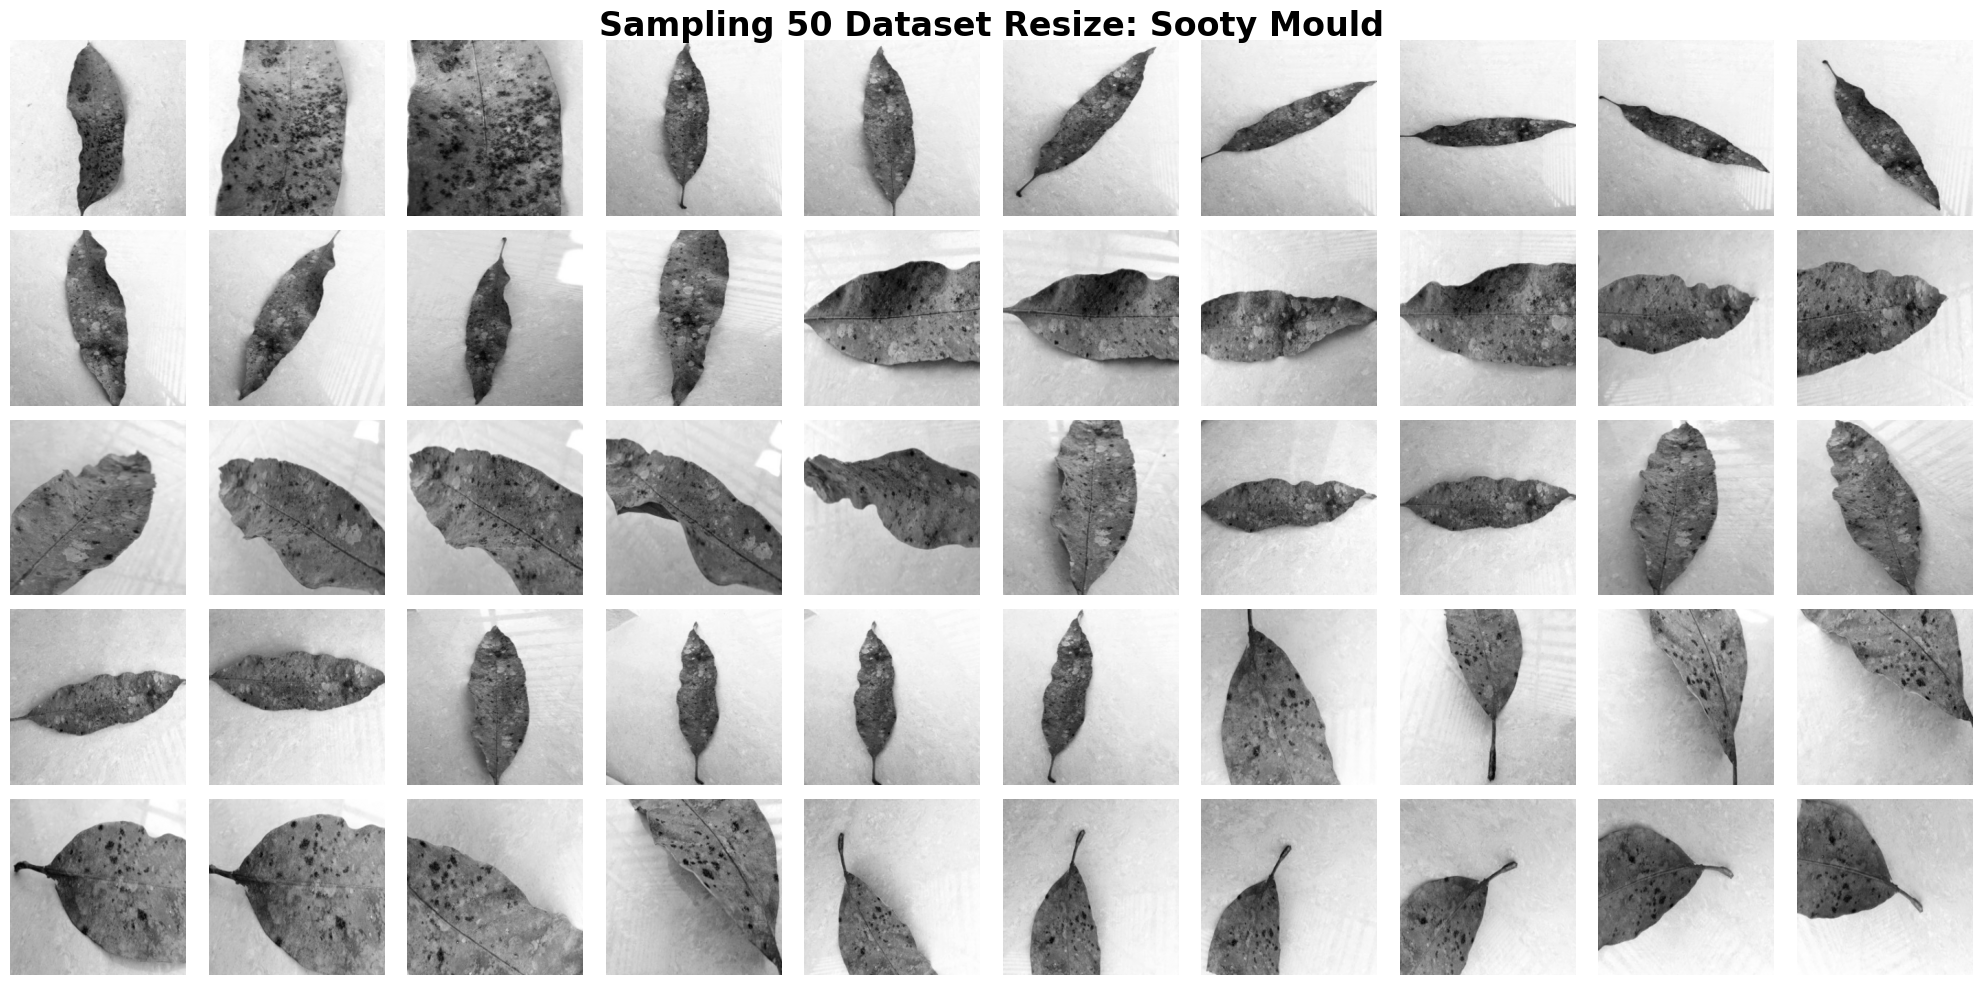

In [4]:
data_gray = []
data_resize = []

print("Memproses Grayscale -> Resize ...")


# =========================
# PREPROCESSING
# =========================
for i in range(len(data)):
    img_bgr = data[i].astype(np.uint8)

    # Grayscale
    img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

    # Resize
    img_resize = cv.resize(img_gray, (256, 256))

   

    data_gray.append(img_gray)
    data_resize.append(img_resize)

# Konversi ke numpy array
data_gray = np.array(data_gray, dtype=object)
data_resize = np.array(data_resize, dtype=object)

print("Pemrosesan Selesai! Menampilkan hasil Resize...")

# =========================
# VISUALISASI
# =========================
for nama_kelas in target_classes:

    indeks_kelas = []

    for idx in range(len(labels)):
        if labels[idx] == nama_kelas:
            indeks_kelas.append(idx)

    fig, axes = plt.subplots(5, 10, figsize=(20, 10))

    fig.suptitle(
        f"Sampling 50 Dataset Resize: {nama_kelas}",
        fontsize=24,
        fontweight='bold'
    )

    for i, ax in enumerate(axes.flat):

        if i < len(indeks_kelas):
            img_tampil = data_resize[indeks_kelas[i]].astype(np.uint8)
            ax.imshow(img_tampil, cmap='gray')

        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

## Preprocessing Citra

Setelah dataset berhasil dimuat, tahap selanjutnya adalah preprocessing citra yang bertujuan untuk meningkatkan kualitas informasi visual sebelum dilakukan ekstraksi fitur menggunakan Gray Level Co-occurrence Matrix (GLCM). Meskipun dataset yang digunakan memiliki latar belakang (*background*) yang relatif bersih dan objek daun sudah terlihat jelas, preprocessing tetap diperlukan untuk memperjelas karakteristik visual yang menjadi pembeda antar kelas penyakit. Pada proyek ini, preprocessing dilakukan melalui dua tahapan utama, yaitu grayscale dan resize.

Tahap pertama adalah konversi citra berwarna menjadi citra grayscale menggunakan fungsi `cv.cvtColor()`. Proses ini dilakukan karena metode GLCM bekerja berdasarkan hubungan antar tingkat keabuan piksel dan tidak memanfaatkan informasi warna secara langsung. Dengan mengubah citra menjadi grayscale, proses komputasi menjadi lebih sederhana sekaligus memfokuskan analisis pada pola tekstur yang terdapat pada permukaan daun.

Setelah itu, citra diubah ukurannya menjadi **256 × 256 piksel** menggunakan fungsi `cv.resize()`. Proses resize dilakukan untuk menyeragamkan ukuran seluruh citra dalam dataset sehingga setiap citra memiliki representasi yang konsisten saat dilakukan ekstraksi fitur. Ukuran 256 × 256 dipilih karena masih mampu mempertahankan detail penting pada daun mangga, seperti bentuk tepi daun, bercak penyakit, maupun pola tekstur permukaan daun, tanpa menghasilkan beban komputasi yang terlalu besar. Dengan ukuran yang seragam, fitur yang dihasilkan dari setiap citra dapat dibandingkan secara lebih adil dan konsisten.

Meskipun latar belakang dataset sudah bersih, proses preprocessing tetap diperlukan untuk memastikan karakteristik visual setiap kelas dapat direpresentasikan dengan lebih baik sebelum dilakukan ekstraksi fitur. Berdasarkan pengamatan terhadap dataset, kelas **Bacterial Canker** memiliki bentuk tepi daun yang cenderung tidak beraturan dan tampak bergerigi pada beberapa bagian. Pada kelas **Die Back**, daun terlihat mengalami perubahan kondisi yang ditandai dengan warna yang lebih cokelat, bentuk yang melengkung, serta tampak seperti daun yang mulai mengering atau mati. Sementara itu, kelas **Sooty Mould** menunjukkan adanya bercak atau area tertentu pada permukaan daun yang membedakannya dari daun sehat. Perbedaan-perbedaan visual tersebut perlu dipertahankan agar karakteristik setiap kelas dapat ditangkap dengan baik pada tahap ekstraksi fitur.

Hasil preprocessing kemudian disimpan ke dalam variabel `data_gray` dan `data_resize`. Namun, citra hasil resize digunakan sebagai keluaran akhir preprocessing karena telah memiliki ukuran yang seragam dan siap digunakan pada tahap ekstraksi fitur GLCM. Untuk mendukung analisis visual, program juga menampilkan sampel citra hasil preprocessing dari setiap kelas sehingga karakteristik masing-masing penyakit dapat diamati secara langsung sebelum memasuki tahap ekstraksi fitur.

In [5]:
print("Memulai proses Ekstraksi Fitur GLCM sesuai template...")

# === 1. DEFINE FUNCTIONS SESUAI TEMPLATE ===
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # --- PERBAIKAN DI SINI ---
    # Memaksa tipe data gambar menjadi uint8 agar skimage tidak error
    img_safe = image.astype(np.uint8)
    
    # Mengembalikan matrix glcm dari image 
    glcm = graycomatrix(img_safe, [1], angles, 256, symmetric=True, normed=True)
    return glcm

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

# === 2. EXTRACT MATRIX GLCM UNTUK SETIAP DERAJAT ===
dataPreprocessed = data_resize  # Memetakan hasil preprocessing akhir lu ke template

Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

# === 3. COPAS ARRAY PENAMPUNG DARI TEMPLATE ===
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

# === 4. HITUNG PROPERTI TEKSTUR PER DERAJAT ===
for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

for i in range(len(dataPreprocessed)):  
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

# === 5. WRITE THE EXTRACTION'S RESULTS TO CSV ===
dataTable = {
    'Filename': file_name, 
    'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)
hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1.csv')

print("Ekstraksi Fitur Berhasil Selesai & Disimpan ke CSV!")
hasilEkstrak

Memulai proses Ekstraksi Fitur GLCM sesuai template...
Ekstraksi Fitur Berhasil Selesai & Disimpan ke CSV!


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,IMG_20211106_120700 (Custom).jpg,Bacterial Canker,34.309268,73.498270,33.456403,44.100838,0.457309,0.379305,0.423660,0.369883,...,0.003585,0.002914,0.064056,0.055475,0.059872,0.053981,0.988766,0.976011,0.989049,0.985606
1,IMG_20211106_120807 (Custom).jpg,Bacterial Canker,38.264338,69.338608,30.592938,51.445721,0.474909,0.398799,0.443980,0.385965,...,0.003520,0.002834,0.063132,0.054857,0.059328,0.053236,0.987927,0.978187,0.990349,0.983816
2,IMG_20211106_120811 (Custom).jpg,Bacterial Canker,32.440732,78.246782,38.135126,44.210411,0.438021,0.361937,0.409783,0.352972,...,0.002985,0.002390,0.057704,0.050166,0.054637,0.048892,0.990922,0.978169,0.989331,0.987665
3,IMG_20211106_120815 (Custom).jpg,Bacterial Canker,26.745190,75.804337,39.600475,42.522322,0.480357,0.396731,0.447363,0.388406,...,0.003732,0.003014,0.065051,0.056229,0.061089,0.054899,0.991829,0.976912,0.987905,0.987049
4,IMG_20211106_120823 (Custom).jpg,Bacterial Canker,17.189874,60.799323,40.879044,43.971565,0.469712,0.388034,0.431360,0.371039,...,0.002676,0.002154,0.055649,0.047899,0.051731,0.046408,0.992946,0.975126,0.983242,0.982010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,IMG_20211212_150412 (Custom).jpg,Sooty Mould,48.950015,65.101161,18.486183,60.835494,0.558929,0.432598,0.493087,0.447151,...,0.001863,0.001675,0.051312,0.040223,0.043161,0.040923,0.995132,0.993529,0.998160,0.993953
1996,IMG_20211212_150421 (Custom).jpg,Sooty Mould,52.266958,48.028512,16.370221,78.480861,0.619023,0.498487,0.563487,0.516257,...,0.002462,0.002255,0.058074,0.046140,0.049619,0.047487,0.993724,0.994241,0.998032,0.990590
1997,IMG_20211212_150513 (Custom).jpg,Sooty Mould,66.010003,78.720261,14.068919,72.429419,0.538092,0.428850,0.485875,0.438984,...,0.002522,0.002204,0.057098,0.046373,0.050220,0.046943,0.993654,0.992437,0.998647,0.993041
1998,IMG_20211212_150516 (Custom).jpg,Sooty Mould,65.743382,67.684245,16.213128,85.520138,0.546805,0.432580,0.488759,0.442491,...,0.002614,0.002319,0.058796,0.047434,0.051124,0.048156,0.993470,0.993286,0.998389,0.991517


Ekstraksi Fitur Tekstur Menggunakan GLCM

Setelah melalui tahap preprocessing, citra hasil resize digunakan sebagai masukan pada proses ekstraksi fitur tekstur menggunakan metode Gray Level Co-occurrence Matrix (GLCM). Berbeda dengan manusia yang dapat mengenali penyakit melalui pengamatan visual, model klasifikasi memerlukan representasi berupa nilai-nilai fitur yang mampu menggambarkan karakteristik setiap kelas penyakit.

Pada proyek ini, GLCM dipilih karena mampu merepresentasikan pola tekstur citra melalui hubungan antar piksel yang bertetangga. Pemilihan metode ini sangat sesuai dengan dataset daun mangga yang digunakan karena perbedaan antar kelas lebih banyak ditunjukkan oleh perubahan tekstur permukaan daun dibandingkan bentuk objek secara keseluruhan. Karakteristik seperti bercak pada daun, kerusakan jaringan, ketidakteraturan permukaan, maupun perubahan pola intensitas piksel dapat direpresentasikan dengan baik melalui fitur-fitur tekstur yang dihasilkan oleh GLCM.

Sebelum matriks GLCM dibentuk, setiap citra hasil preprocessing dikonversi ke dalam format uint8 menggunakan fungsi astype(np.uint8). Langkah ini dilakukan untuk memastikan nilai intensitas piksel berada pada rentang 0–255 sehingga dapat diproses dengan baik oleh fungsi graycomatrix(). Selanjutnya, matriks GLCM dibentuk menggunakan jarak antar piksel sebesar 1 piksel dengan empat orientasi sudut, yaitu 0°, 45°, 90°, dan 135°.

Penggunaan empat sudut tersebut bertujuan untuk menangkap pola tekstur dari berbagai arah. Pada citra daun mangga, pola penyakit tidak selalu muncul dalam orientasi yang sama. Beberapa bercak dapat menyebar secara horizontal, vertikal, maupun diagonal. Oleh karena itu, penggunaan satu sudut saja berpotensi menyebabkan sebagian informasi tekstur tidak terwakili dengan baik. Dengan memanfaatkan empat arah pengamatan, karakteristik tekstur daun dapat direpresentasikan secara lebih lengkap sehingga meningkatkan kemampuan model dalam membedakan setiap kelas penyakit.

Setelah matriks GLCM diperoleh, dilakukan perhitungan beberapa fitur tekstur yang dianggap mampu menggambarkan kondisi permukaan daun secara komprehensif. Fitur Contrast digunakan untuk mengukur tingkat perbedaan intensitas antar piksel yang berdekatan. Nilai contrast yang tinggi menunjukkan adanya variasi intensitas yang besar pada citra, yang sering kali muncul pada daun dengan bercak atau kerusakan yang cukup jelas.

Fitur Homogeneity digunakan untuk mengukur tingkat keseragaman distribusi intensitas piksel. Daun yang memiliki tekstur lebih seragam cenderung menghasilkan nilai homogeneity yang lebih tinggi dibandingkan daun yang mengalami kerusakan atau memiliki banyak variasi tekstur akibat penyakit.

Fitur Dissimilarity mengukur tingkat ketidakmiripan antar piksel yang bertetangga. Semakin tinggi nilai dissimilarity, semakin besar perbedaan tekstur yang terdapat pada citra. Fitur ini penting karena beberapa penyakit daun menghasilkan pola permukaan yang lebih tidak beraturan dibandingkan daun sehat.

Fitur Correlation digunakan untuk mengukur hubungan statistik antar piksel pada citra. Nilai correlation dapat memberikan gambaran mengenai keteraturan pola tekstur yang terbentuk pada permukaan daun. Tekstur yang lebih terstruktur cenderung menghasilkan nilai correlation yang berbeda dibandingkan tekstur yang mengalami kerusakan akibat penyakit.

Selain itu, digunakan pula fitur Angular Second Moment (ASM) dan Energy yang menggambarkan tingkat keteraturan distribusi piksel pada citra. Kedua fitur ini sering digunakan untuk membedakan tekstur yang seragam dengan tekstur yang kompleks. Daun sehat umumnya memiliki pola tekstur yang lebih konsisten dibandingkan daun yang mengalami gangguan akibat penyakit, sehingga fitur ini berpotensi memberikan informasi diskriminatif yang penting bagi model klasifikasi.

Untuk melengkapi informasi tekstur, proyek ini juga menghitung Entropy dari matriks GLCM. Entropy digunakan untuk mengukur tingkat kompleksitas atau ketidakteraturan tekstur pada citra. Semakin tinggi nilai entropy, semakin kompleks distribusi tekstur yang terdapat pada daun. Fitur ini sangat relevan karena penyakit pada daun umumnya menyebabkan munculnya pola-pola yang lebih tidak beraturan dibandingkan kondisi daun sehat.

Setelah seluruh fitur dihitung pada masing-masing sudut orientasi, diperoleh total 28 fitur tekstur, yang terdiri dari tujuh fitur GLCM pada empat arah pengamatan. Seluruh nilai fitur kemudian disimpan bersama informasi nama file dan label kelas ke dalam file hasil_ekstraksi_percobaan2.csv menggunakan library Pandas. Penyimpanan dalam format CSV bertujuan untuk memudahkan proses pengelolaan data sekaligus memisahkan tahap ekstraksi fitur dari tahap klasifikasi.

Berdasarkan proses ekstraksi yang dilakukan, GLCM berhasil mengubah citra daun mangga yang semula berupa data visual menjadi sekumpulan fitur numerik yang merepresentasikan karakteristik tekstur setiap kelas. Fitur-fitur tersebut diharapkan mampu menangkap perbedaan antara daun Healthy, Bacterial Canker, Die Back, dan Sooty Mould, sehingga model klasifikasi dapat mengenali pola penyakit dengan lebih akurat dibandingkan apabila hanya menggunakan informasi citra mentah secara langsung.

In [6]:
x_new = hasilEkstrak.drop(
    columns=['Label', 'Filename']
)

y = hasilEkstrak['Label']

print("Jumlah fitur:", x_new.shape[1])

Jumlah fitur: 28


## Pembentukan Dataset Fitur

Setelah proses ekstraksi fitur selesai, hasil ekstraksi yang tersimpan pada file `hasil_ekstraksi_percobaan2.csv` digunakan untuk membentuk dataset yang akan diproses pada tahap klasifikasi. Pada tahap ini, kolom **Filename** dan **Label** dipisahkan dari data fitur menggunakan fungsi `drop()`. Kolom **Filename** tidak digunakan dalam proses klasifikasi karena hanya berfungsi sebagai identitas citra, sedangkan kolom **Label** digunakan sebagai target kelas yang akan diprediksi oleh model.

Variabel `x_new` berisi seluruh fitur numerik hasil ekstraksi GLCM yang akan digunakan sebagai data masukan (input), sedangkan variabel `y` berisi label kelas yang merepresentasikan kondisi daun mangga, yaitu **Bacterial Canker**, **Die Back**, **Healthy**, dan **Sooty Mould**.

Berdasarkan hasil ekstraksi yang telah dilakukan, diperoleh total **28 fitur tekstur** yang digunakan sebagai representasi setiap citra. Jumlah tersebut berasal dari kombinasi **7 fitur GLCM**, yaitu Contrast, Homogeneity, Dissimilarity, Entropy, ASM, Energy, dan Correlation yang dihitung pada **4 orientasi sudut**, yaitu 0°, 45°, 90°, dan 135°. Kombinasi tersebut menghasilkan total 28 fitur yang mampu merepresentasikan karakteristik tekstur daun dari berbagai arah pengamatan.

Penggunaan 28 fitur ini bertujuan untuk memberikan informasi tekstur yang lebih lengkap kepada model klasifikasi. Setiap fitur memiliki peran dalam menggambarkan kondisi permukaan daun, mulai dari tingkat keseragaman tekstur, perbedaan intensitas piksel, hubungan antar piksel, hingga tingkat kompleksitas tekstur. Dengan memanfaatkan fitur dari berbagai orientasi sudut, informasi yang diperoleh menjadi lebih representatif karena pola penyakit pada daun tidak selalu muncul dalam arah yang sama.

Hasil pembentukan dataset fitur ini menghasilkan data numerik yang siap digunakan pada tahap pembagian data (training dan testing), normalisasi fitur, serta proses pelatihan model klasifikasi menggunakan algoritma Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN).

In [7]:
# === 1. SPLITTING DATA ===
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    x_new,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# === 2. FEATURE NORMALIZATION ===
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Pembagian Data dan Normalisasi Fitur

Setelah dataset fitur berhasil dibentuk, tahap selanjutnya adalah membagi data menjadi data latih (*training data*) dan data uji (*testing data*) menggunakan fungsi `train_test_split()` dari Scikit-Learn. Pada proyek ini digunakan skenario pembagian data sebesar **80% untuk training** dan **20% untuk testing** dengan parameter `test_size=0.2`.

Pembagian data dilakukan untuk memastikan bahwa model tidak hanya diuji menggunakan data yang telah dipelajari sebelumnya. Data training digunakan untuk membangun model dan mempelajari pola dari setiap kelas penyakit daun mangga, sedangkan data testing digunakan untuk mengevaluasi kemampuan model dalam melakukan klasifikasi pada data yang belum pernah dilihat sebelumnya. Dengan demikian, performa yang diperoleh dapat memberikan gambaran yang lebih objektif terhadap kemampuan model dalam kondisi nyata.

Parameter `stratify=y` digunakan untuk mempertahankan proporsi jumlah data pada setiap kelas selama proses pembagian data. Karena dataset terdiri dari empat kelas dengan jumlah yang sama, yaitu masing-masing 500 citra, penggunaan stratifikasi memastikan bahwa distribusi kelas pada data training dan testing tetap seimbang. Hal ini penting untuk menghindari kondisi di mana suatu kelas memiliki jumlah data yang jauh lebih sedikit pada salah satu subset sehingga dapat memengaruhi proses pelatihan maupun evaluasi model.

Selain itu, parameter `random_state=42` digunakan untuk memastikan proses pembagian data selalu menghasilkan kombinasi data yang sama setiap kali program dijalankan. Dengan demikian, hasil eksperimen dapat direproduksi kembali secara konsisten.

Setelah proses splitting selesai, dilakukan tahap **normalisasi fitur** menggunakan metode **Z-Score Standardization**. Normalisasi dilakukan dengan mengurangi setiap nilai fitur terhadap rata-rata data training dan kemudian membaginya dengan standar deviasi data training. Tujuan utama dari proses ini adalah menyamakan skala seluruh fitur sehingga tidak ada fitur tertentu yang memiliki pengaruh lebih besar hanya karena memiliki rentang nilai yang lebih tinggi.

Normalisasi menjadi penting karena fitur-fitur GLCM yang digunakan memiliki rentang nilai yang berbeda-beda. Sebagai contoh, nilai Contrast dapat memiliki rentang yang jauh lebih besar dibandingkan nilai Correlation atau Homogeneity. Jika perbedaan skala ini tidak ditangani, maka beberapa algoritma machine learning dapat lebih terpengaruh oleh fitur yang memiliki nilai besar dibandingkan fitur lainnya.

Pada implementasi ini, rata-rata (*mean*) dan standar deviasi (*standard deviation*) dihitung menggunakan data training, kemudian parameter tersebut digunakan untuk menormalisasi data training dan data testing. Pendekatan ini dilakukan untuk menghindari *data leakage*, yaitu kondisi ketika informasi dari data testing secara tidak sengaja ikut digunakan selama proses pelatihan model. Dengan menggunakan statistik yang hanya berasal dari data training, proses evaluasi model menjadi lebih valid dan mencerminkan kondisi penerapan model pada data baru.

Melalui tahap splitting dan normalisasi ini, diperoleh data yang lebih terstruktur, memiliki distribusi fitur yang lebih seimbang, serta siap digunakan pada proses pelatihan dan evaluasi model klasifikasi menggunakan algoritma Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN).

In [8]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Inisialisasi Model Klasifikasi dan Fungsi Evaluasi

Setelah data berhasil dibagi dan dinormalisasi, tahap berikutnya adalah menyiapkan model klasifikasi yang akan digunakan untuk mengenali penyakit daun mangga berdasarkan fitur tekstur hasil ekstraksi GLCM. Pada proyek ini digunakan tiga algoritma machine learning yang memiliki pendekatan klasifikasi yang berbeda, yaitu **Random Forest**, **Support Vector Machine (SVM)**, dan **K-Nearest Neighbor (KNN)**. Penggunaan beberapa algoritma dilakukan untuk membandingkan performa masing-masing model dalam mengklasifikasikan citra daun mangga serta menentukan metode yang memberikan hasil terbaik.

Sebelum proses pelatihan dilakukan, program terlebih dahulu membuat fungsi `generateClassificationReport()`. Fungsi ini digunakan untuk menampilkan hasil evaluasi model yang terdiri dari **classification report**, **confusion matrix**, dan **accuracy score**. Classification report memberikan informasi mengenai nilai precision, recall, dan F1-score untuk setiap kelas, sedangkan confusion matrix digunakan untuk melihat jumlah prediksi yang benar maupun kesalahan klasifikasi pada setiap kategori penyakit. Accuracy score digunakan untuk mengukur persentase keseluruhan data yang berhasil diklasifikasikan dengan benar oleh model.

Model pertama yang digunakan adalah **Random Forest Classifier** dengan jumlah pohon keputusan sebanyak **300 estimator** (`n_estimators=300`). Pemilihan Random Forest dilakukan karena algoritma ini mampu menggabungkan banyak pohon keputusan untuk menghasilkan prediksi yang lebih stabil dan mengurangi risiko overfitting. Pada kasus klasifikasi penyakit daun mangga, Random Forest memiliki kemampuan yang baik dalam menangani data dengan jumlah fitur yang cukup banyak serta mampu mempelajari hubungan kompleks antar fitur tekstur hasil ekstraksi GLCM.

Model kedua adalah **Support Vector Machine (SVM)** dengan kernel **Radial Basis Function (RBF)**. Kernel RBF dipilih karena mampu menangani hubungan non-linear antar fitur yang sering ditemukan pada data citra. Karakteristik tekstur daun yang berbeda-beda pada setiap kelas penyakit memungkinkan terbentuknya batas pemisah yang tidak linear, sehingga penggunaan kernel RBF diharapkan dapat membantu model menemukan pemisahan kelas yang lebih optimal dibandingkan pendekatan linear.

Model ketiga yang digunakan adalah **K-Nearest Neighbor (KNN)** dengan parameter `n_neighbors=5`. Algoritma ini melakukan klasifikasi berdasarkan kedekatan suatu data dengan lima tetangga terdekatnya dalam ruang fitur. Pemilihan nilai K sebesar 5 bertujuan untuk menghasilkan keseimbangan antara sensitivitas model terhadap data dan kemampuan generalisasi. KNN dipilih karena merupakan salah satu metode klasifikasi yang sederhana namun sering memberikan performa yang baik pada data yang telah melalui proses normalisasi.

Penggunaan ketiga algoritma tersebut memungkinkan dilakukan analisis komparatif terhadap performa model dalam mengenali empat kelas daun mangga, yaitu **Bacterial Canker**, **Die Back**, **Healthy**, dan **Sooty Mould**. Melalui perbandingan hasil evaluasi yang diperoleh pada tahap berikutnya, dapat diketahui algoritma mana yang paling efektif dalam memanfaatkan fitur tekstur GLCM untuk proses klasifikasi penyakit daun mangga.

In [9]:
# === 1. TRAIN & EVALUATE RANDOM FOREST ===
print("==================================================")
print("              RANDOM FOREST CLASSIFIER            ")
print("==================================================")
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_rf = rf.predict(X_train)
generateClassificationReport(y_train, y_pred_train_rf)

print("\n------Testing Set------")
y_pred_test_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_test_rf)

              RANDOM FOREST CLASSIFIER            
------Training Set------
                  precision    recall  f1-score   support

Bacterial Canker       1.00      1.00      1.00       400
        Die Back       1.00      1.00      1.00       400
         Healthy       1.00      1.00      1.00       400
     Sooty Mould       1.00      1.00      1.00       400

        accuracy                           1.00      1600
       macro avg       1.00      1.00      1.00      1600
    weighted avg       1.00      1.00      1.00      1600

[[400   0   0   0]
 [  0 400   0   0]
 [  0   0 400   0]
 [  0   0   0 400]]
Accuracy: 1.0

------Testing Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.98      0.95      0.96       100
        Die Back       0.96      0.96      0.96       100
         Healthy       0.82      0.95      0.88       100
     Sooty Mould       0.94      0.82      0.88       100

        accuracy                           0.92  

Pelatihan dan Evaluasi Model Random Forest

Model Random Forest dilatih menggunakan data training yang telah diproses sebelumnya melalui tahap preprocessing sederhana, yaitu grayscale dan resize. Setelah itu, model dievaluasi menggunakan data training dan data testing untuk melihat kemampuan klasifikasi berdasarkan fitur tekstur GLCM pada citra daun mangga.

Hasil pelatihan menunjukkan bahwa model memperoleh nilai accuracy sebesar 100% pada data training. Seluruh kelas berhasil diklasifikasikan dengan benar, yang ditunjukkan oleh nilai precision, recall, dan F1-score yang mencapai 1.00 pada setiap kategori. Confusion matrix juga menunjukkan tidak adanya kesalahan prediksi pada data training, di mana seluruh sampel berhasil dipetakan sesuai kelasnya masing-masing.

Nilai akurasi yang sempurna pada data training menunjukkan bahwa fitur tekstur GLCM yang digunakan mampu memisahkan karakteristik setiap kelas dengan sangat baik pada data latih. Random Forest dapat mempelajari pola dari fitur yang diekstraksi secara optimal sehingga tidak terdapat sampel yang salah klasifikasi pada data training.

Namun, hasil yang lebih penting terlihat pada data testing karena data ini tidak digunakan selama proses pelatihan model. Pada data testing diperoleh nilai accuracy sebesar 92%, yang menunjukkan bahwa sebagian besar citra masih dapat diklasifikasikan dengan benar oleh model meskipun menghadapi data yang belum pernah dilihat sebelumnya.

Berdasarkan classification report, performa tiap kelas pada data testing menunjukkan hasil yang cukup baik. Kelas Bacterial Canker, Die Back, Healthy, dan Sooty Mould masih memiliki nilai precision, recall, dan F1-score yang relatif tinggi, meskipun tidak lagi sempurna seperti pada data training. Hal ini menunjukkan adanya beberapa kesalahan prediksi pada data testing yang menyebabkan penurunan performa secara keseluruhan.

Confusion matrix pada data testing menunjukkan bahwa kesalahan prediksi paling sering terjadi pada kelas yang memiliki kemiripan visual tinggi. Beberapa sampel Sooty Mould dan Die Back masih tertukar dengan kelas lain, yang mengindikasikan bahwa fitur tekstur GLCM pada beberapa citra masih memiliki nilai yang berdekatan sehingga model sedikit kesulitan dalam membedakan kelas tertentu.

Perbedaan antara akurasi training (100%) dan testing (92%) menunjukkan bahwa model tidak hanya menghafal data training, tetapi juga masih mampu melakukan generalisasi dengan cukup baik pada data baru. Penurunan akurasi ini tergolong wajar dalam proses klasifikasi citra, terutama pada dataset dengan karakteristik visual yang mirip antar kelas.

Secara keseluruhan, kombinasi preprocessing sederhana (grayscale dan resize), ekstraksi fitur GLCM, dan algoritma Random Forest menghasilkan performa klasifikasi yang baik. Dengan akurasi testing sebesar 92%, model sudah cukup efektif dalam mengenali empat kelas penyakit daun mangga (Bacterial Canker, Die Back, Healthy, dan Sooty Mould) berdasarkan fitur tekstur yang diekstraksi.

In [10]:
# === 2. TRAIN & EVALUATE SVM ===
print("\n==================================================")
print("                   SVM CLASSIFIER                 ")
print("==================================================")
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_svm = svm.predict(X_train)
generateClassificationReport(y_train, y_pred_train_svm)

print("\n------Testing Set------")
y_pred_test_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_test_svm)


                   SVM CLASSIFIER                 
------Training Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.97      0.91      0.94       400
        Die Back       0.99      0.96      0.97       400
         Healthy       0.84      0.93      0.88       400
     Sooty Mould       0.84      0.83      0.83       400

        accuracy                           0.91      1600
       macro avg       0.91      0.91      0.91      1600
    weighted avg       0.91      0.91      0.91      1600

[[363   0   0  37]
 [  0 383  15   2]
 [  0   5 371  24]
 [ 11   0  58 331]]
Accuracy: 0.905

------Testing Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.98      0.87      0.92       100
        Die Back       0.97      0.96      0.96       100
         Healthy       0.79      0.93      0.85       100
     Sooty Mould       0.80      0.75      0.77       100

        accuracy                           0.8

Pelatihan dan Evaluasi Model Support Vector Machine (SVM)

Model Support Vector Machine (SVM) dilatih menggunakan data training yang telah diproses sebelumnya melalui tahap preprocessing sederhana, yaitu grayscale dan resize. Selanjutnya, model dievaluasi menggunakan data training dan data testing untuk mengukur kemampuan klasifikasi berdasarkan fitur tekstur GLCM pada citra daun mangga.

Hasil pelatihan menunjukkan bahwa model memperoleh nilai accuracy sebesar 90,5% pada data training. Berdasarkan classification report, kelas Bacterial Canker dan Die Back memiliki performa yang relatif tinggi dengan nilai precision dan recall di atas 0,90. Namun, pada kelas Healthy dan Sooty Mould terlihat penurunan performa, terutama pada precision dan recall yang berada di bawah kelas lainnya.

Confusion matrix pada data training menunjukkan adanya beberapa kesalahan klasifikasi, terutama antara kelas Healthy dan Sooty Mould, serta sebagian kecil antara Die Back dengan kelas lainnya. Hal ini mengindikasikan bahwa beberapa fitur tekstur dari kelas tersebut memiliki kemiripan sehingga model SVM mengalami kesulitan dalam memisahkan batas antar kelas secara sempurna.

Pada data testing, model memperoleh nilai accuracy sebesar 87,75%, yang menunjukkan bahwa kemampuan generalisasi model sedikit menurun ketika dihadapkan pada data yang belum pernah dilihat sebelumnya. Penurunan ini masih dalam batas wajar dan menunjukkan bahwa model tidak sepenuhnya overfitting, meskipun terdapat selisih performa antara data training dan testing.

Berdasarkan hasil classification report pada data testing, penurunan performa paling terlihat pada kelas Sooty Mould dan Healthy, yang memiliki beberapa kesalahan prediksi terhadap kelas lain. Confusion matrix juga memperlihatkan bahwa sebagian besar error terjadi pada kelas-kelas yang memiliki karakteristik visual yang mirip, sehingga batas pemisahan antar kelas tidak selalu dapat dipisahkan secara optimal oleh SVM.

Secara keseluruhan, model SVM dengan fitur GLCM mampu memberikan hasil klasifikasi yang cukup baik, dengan akurasi testing sebesar 87,75%. Meskipun tidak setinggi Random Forest, model ini tetap mampu mengenali pola utama pada penyakit daun mangga (Bacterial Canker, Die Back, Healthy, dan Sooty Mould) dengan performa yang stabil dan konsisten pada data training maupun testing.

In [11]:
# === 3. TRAIN & EVALUATE KNN ===
print("\n==================================================")
print("                   KNN CLASSIFIER                 ")
print("==================================================")
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_knn = knn.predict(X_train)
generateClassificationReport(y_train, y_pred_train_knn)

print("\n------Testing Set------")
y_pred_test_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_test_knn)


                   KNN CLASSIFIER                 
------Training Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.98      0.95      0.96       400
        Die Back       0.98      0.96      0.97       400
         Healthy       0.88      0.91      0.89       400
     Sooty Mould       0.87      0.89      0.88       400

        accuracy                           0.93      1600
       macro avg       0.93      0.93      0.93      1600
    weighted avg       0.93      0.93      0.93      1600

[[380   0   0  20]
 [  0 383  15   2]
 [  0   6 365  29]
 [  8   1  36 355]]
Accuracy: 0.926875

------Testing Set------
                  precision    recall  f1-score   support

Bacterial Canker       1.00      0.91      0.95       100
        Die Back       0.96      0.95      0.95       100
         Healthy       0.79      0.88      0.83       100
     Sooty Mould       0.82      0.81      0.81       100

        accuracy                           

Pelatihan dan Evaluasi Model K-Nearest Neighbors (KNN)

Model K-Nearest Neighbors (KNN) dilatih menggunakan data training yang telah diproses sebelumnya melalui tahap preprocessing sederhana, yaitu grayscale dan resize. Selanjutnya, model dievaluasi menggunakan data training dan data testing untuk melihat kemampuan klasifikasi berdasarkan fitur tekstur GLCM pada citra daun mangga.

Hasil pelatihan menunjukkan bahwa model memperoleh nilai accuracy sebesar 92,69% pada data training. Berdasarkan classification report, kelas Bacterial Canker dan Die Back memiliki performa yang tinggi dengan precision dan recall di atas 0,95. Sementara itu, kelas Healthy dan Sooty Mould menunjukkan performa yang sedikit lebih rendah, meskipun masih berada pada kisaran yang cukup baik.

Confusion matrix pada data training menunjukkan adanya beberapa kesalahan klasifikasi, terutama pada kelas Healthy dan Sooty Mould yang saling tertukar dengan kelas lain. Hal ini menunjukkan bahwa beberapa fitur GLCM pada kedua kelas tersebut memiliki kemiripan sehingga model KNN tidak selalu dapat membedakan dengan sempurna.

Pada data testing, model memperoleh nilai accuracy sebesar 88,75%, yang menunjukkan bahwa kemampuan generalisasi model cukup baik meskipun mengalami penurunan dibandingkan data training. Hal ini mengindikasikan bahwa model masih mampu mengenali pola baru, tetapi dengan tingkat kesalahan yang sedikit lebih tinggi pada data yang belum pernah dilihat sebelumnya.

Berdasarkan classification report pada data testing, penurunan performa paling terlihat pada kelas Sooty Mould dan Healthy, yang masih sering mengalami salah klasifikasi terhadap kelas lain. Confusion matrix juga memperlihatkan bahwa sebagian error terjadi pada kelas-kelas dengan karakteristik visual yang mirip, sehingga jarak antar fitur tidak selalu mampu memisahkan kelas secara optimal pada metode KNN.

Secara keseluruhan, model KNN dengan fitur GLCM menghasilkan performa yang cukup baik dengan akurasi testing sebesar 88,75%. Meskipun sedikit di bawah Random Forest, model ini tetap mampu mengenali empat kelas penyakit daun mangga (Bacterial Canker, Die Back, Healthy, dan Sooty Mould) dengan tingkat akurasi yang stabil dan konsisten.

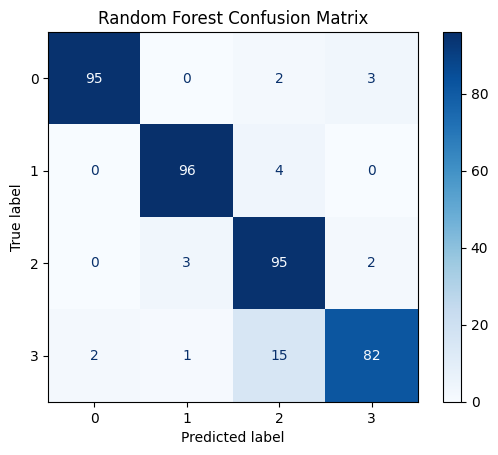

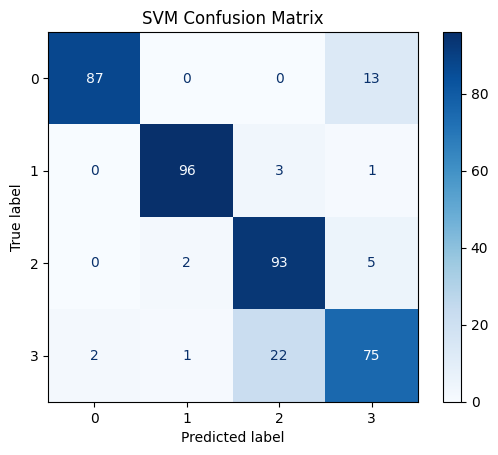

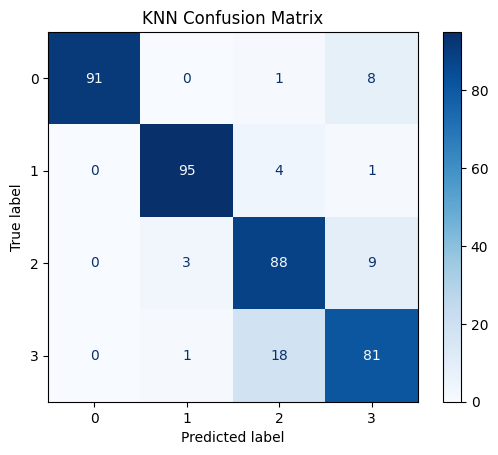

In [12]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

## Visualisasi dan Analisis Confusion Matrix
Untuk memperoleh pemahaman yang lebih mendalam mengenai performa setiap model, dilakukan visualisasi confusion matrix pada data testing. Confusion matrix digunakan untuk melihat distribusi prediksi yang benar maupun kesalahan klasifikasi pada masing-masing kelas sehingga dapat diketahui kelas mana yang paling mudah maupun paling sulit dikenali oleh model.

### Random Forest
Berdasarkan confusion matrix Random Forest, sebagian besar sampel berhasil diklasifikasikan dengan benar pada setiap kelas. Kelas pertama berhasil diprediksi benar sebanyak 95 data dari total 100 data, sedangkan 3 data lainnya salah diklasifikasikan ke kelas keempat dan 2 data ke kelas ketiga. Pada kelas kedua, model berhasil mengenali 96 data dengan benar dan hanya melakukan kesalahan pada 4 data. Kelas ketiga juga menunjukkan performa yang baik dengan 95 prediksi benar, sementara kelas keempat berhasil dikenali sebanyak 82 data.

Meskipun secara keseluruhan menghasilkan akurasi tertinggi, masih terlihat adanya kesalahan klasifikasi yang cukup dominan pada kelas keempat. Sebanyak 15 sampel dari kelas keempat diprediksi sebagai kelas ketiga. Hal ini menunjukkan bahwa karakteristik tekstur antara kedua kelas tersebut memiliki kemiripan yang cukup tinggi sehingga beberapa sampel sulit dibedakan oleh model. Namun demikian, sebagian besar nilai masih terkonsentrasi pada diagonal utama confusion matrix yang menandakan bahwa Random Forest mampu mempelajari pola data dengan sangat baik.

Hasil ini sejalan dengan akurasi testing sebesar 92,0% (Total benar: 95+96+95+82 = 368 dari 400 data), yang menunjukkan bahwa Random Forest menjadi model dengan performa terbaik pada penelitian ini.

### Support Vector Machine (SVM)
Confusion matrix SVM menunjukkan pola yang sedikit berbeda dibandingkan Random Forest. Pada kelas pertama, model berhasil mengenali 87 data dengan benar namun masih salah mengklasifikasikan 13 data ke kelas keempat. Kelas kedua menunjukkan performa yang sangat baik dengan 96 prediksi benar dari 100 data. Kelas ketiga berhasil dikenali sebanyak 93 data, sedangkan kelas keempat berhasil dikenali sebanyak 75 data.

Kesalahan terbesar juga terlihat pada kelas keempat yang cukup sering diprediksi sebagai kelas ketiga. Sebanyak 22 sampel dari kelas keempat berpindah ke kelas ketiga. Jumlah ini lebih tinggi dibandingkan Random Forest sehingga menunjukkan bahwa SVM mengalami kesulitan yang lebih besar dalam membedakan kedua kelas tersebut.

Perbedaan ini mengindikasikan bahwa batas pemisah yang dibentuk oleh SVM belum mampu memisahkan seluruh karakteristik tekstur secara optimal. Meskipun demikian, distribusi prediksi benar masih mendominasi confusion matrix sehingga model tetap mampu memberikan performa yang baik dengan akurasi testing sebesar 87,75% (Total benar: 87+96+93+75 = 351 dari 400 data).

### K-Nearest Neighbor (KNN)
Pada confusion matrix KNN terlihat bahwa sebagian besar data juga berhasil diklasifikasikan dengan benar. Kelas pertama memiliki 91 prediksi benar, kelas kedua memiliki 95 prediksi benar, kelas ketiga memiliki 88 prediksi benar, dan kelas keempat memiliki 81 prediksi benar.

Menariknya, kelas keempat yang sebelumnya cukup sulit dikenali oleh SVM justru menunjukkan peningkatan performa pada KNN. Model berhasil mengenali 81 data dengan benar, lebih tinggi dibandingkan SVM. Hal ini menunjukkan bahwa pendekatan berbasis kedekatan tetangga yang digunakan KNN cukup efektif dalam mengenali pola pada kelas tersebut.

Namun demikian, kesalahan klasifikasi masih terlihat terutama antara kelas ketiga dan kelas keempat. Sebanyak 18 data pada kelas keempat diprediksi sebagai kelas ketiga, sedangkan 9 data pada kelas ketiga diprediksi sebagai kelas keempat. Pola ini kembali menunjukkan bahwa kedua kelas memiliki karakteristik tekstur yang relatif mirip berdasarkan fitur-fitur GLCM yang digunakan.

Secara keseluruhan, KNN menghasilkan distribusi kesalahan yang lebih merata dibandingkan SVM dan mampu mempertahankan performa testing sebesar 88,75% (Total benar: 91+95+88+81 = 355 dari 400 data), sedikit lebih tinggi dibandingkan SVM dan mendekati performa Random Forest.

Perbandingan Ketiga Model
Berdasarkan visualisasi confusion matrix, seluruh model menunjukkan pola yang relatif serupa. Sebagian besar prediksi berada pada diagonal utama yang menunjukkan bahwa fitur tekstur hasil ekstraksi GLCM berhasil merepresentasikan karakteristik setiap kelas dengan cukup baik.

Kesalahan klasifikasi yang paling sering muncul terjadi antara kelas ketiga dan kelas keempat. Kondisi ini mengindikasikan bahwa kedua kelas memiliki pola tekstur yang lebih mirip dibandingkan pasangan kelas lainnya sehingga lebih sulit dibedakan oleh model. Kemiripan tersebut kemungkinan berasal dari kesamaan pola bercak, distribusi intensitas piksel, maupun tingkat kerusakan permukaan daun yang menghasilkan nilai fitur GLCM yang saling berdekatan.

Jika dilihat dari performa keseluruhan, Random Forest menghasilkan akurasi tertinggi sebesar 92,0%, diikuti oleh KNN sebesar 88,75% dan SVM sebesar 87,75%. Meskipun perbedaannya tidak terlalu besar, Random Forest menunjukkan kemampuan terbaik dalam mempertahankan jumlah prediksi benar pada sebagian besar kelas. Sementara itu, KNN menunjukkan performa yang cukup kompetitif dengan distribusi kesalahan yang lebih seimbang, sedangkan SVM menghasilkan jumlah kesalahan yang relatif lebih banyak terutama pada kelas keempat.

Hasil visualisasi confusion matrix ini memperkuat temuan sebelumnya bahwa kombinasi preprocessing, ekstraksi fitur GLCM, dan algoritma klasifikasi yang digunakan telah mampu mengenali penyakit daun mangga dengan baik. Sebagian besar kesalahan yang masih muncul berasal dari kemiripan karakteristik tekstur antar kelas, bukan karena kegagalan model dalam mempelajari pola data secara keseluruhan.